# Analysis of Outcomes

In [148]:
import pandas as pd
df = pd.read_csv("output.csv")

## Likert Scale Plots

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_likert(df, field_value, likert_map):
    """
    Centered (diverging) Likert distribution plot for a single question.
    Lower scores = positive (green, left), higher = negative (red, right).
    Count labels appear at the end of each bar.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns 'field' and 'value'.
    field_value : str
        Value to filter df['field'] on.
    likert_map : dict
        Mapping of Likert categories <-> integer scores.
        Can be {label: score} or {score: label}.
    """

    # --- Validate columns ---
    for col in ["field", "value"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: '{col}'")

    # --- Filter data ---
    filtered = df[df["field"] == field_value].copy()
    if filtered.empty:
        print(f"No data found for field = {field_value}")
        return

    # --- Detect mapping direction ---
    first_key = next(iter(likert_map))
    if isinstance(first_key, str):
        label_to_score = likert_map
        score_to_label = {v: k for k, v in likert_map.items()}
    else:
        score_to_label = likert_map
        label_to_score = {v: k for k, v in likert_map.items()}

    # --- Convert 'value' to numeric ---
    try:
        filtered["score"] = filtered["value"].astype(int)
        filtered["label"] = filtered["score"].map(score_to_label)
    except ValueError:
        filtered["label"] = filtered["value"]
        filtered["score"] = filtered["value"].map(label_to_score)

    # --- Handle unmapped values ---
    if filtered["score"].isna().any():
        unmapped = filtered.loc[filtered["score"].isna(), "value"].unique()
        print(f"⚠️ Unmapped Likert values found: {list(unmapped)}")

    # --- Sort Likert scale order numerically ---
    order = sorted(score_to_label.items(), key=lambda x: x[0])
    scores = [s for s, _ in order]
    labels = [l for _, l in order]
    counts = filtered["label"].value_counts().reindex(labels, fill_value=0)
    total = counts.sum()
    percents = (counts / total) * 100

    # --- Median (neutral) point ---
    min_score, max_score = min(scores), max(scores)
    median_score = int(np.median(scores))
    neutral_label = score_to_label.get(median_score, None)

    # --- Build color map (green → red) ---
    norm_vals = (np.array(scores) - min_score) / (max_score - min_score)
    colors = plt.cm.RdYlGn_r(norm_vals)
    color_map = dict(zip(labels, colors))

    # --- Split sides ---
    neg_labels = [l for s, l in order if s < median_score]
    pos_labels = [l for s, l in order if s > median_score]

    # --- Combine all labels for consistent order ---
    full_order = neg_labels[::-1] + ([neutral_label] if neutral_label else []) + pos_labels

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot negative side (left)
    for l in neg_labels:
        ax.barh(l, -percents[l], color=color_map[l], edgecolor="none")
        ax.text(-percents[l] - 1, l, f"{counts[l]}", va="center", ha="right", fontsize=9, color="#333")

    # Plot neutral if exists
    if neutral_label:
        ax.barh(neutral_label, percents[neutral_label], color=color_map[neutral_label], edgecolor="none")
        ax.text(percents[neutral_label] + 1, neutral_label, f"{counts[neutral_label]}", va="center", ha="left", fontsize=9, color="#333")

    # Plot positive side (right)
    for l in pos_labels:
        ax.barh(l, percents[l], color=color_map[l], edgecolor="none")
        ax.text(percents[l] + 1, l, f"{counts[l]}", va="center", ha="left", fontsize=9, color="#333")

    # --- Aesthetics ---
    ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_xlabel("Percentage of Responses (%)", fontsize=11)
    ax.set_title(f"{field_value}", fontsize=13, weight="bold", pad=12)

    ax.set_xlim(-100, 100)
    ax.set_xticks(np.arange(-100, 101, 25))
    ax.set_xticklabels([f"{abs(x)}%" for x in np.arange(-100, 101, 25)])
    ax.set_yticks(full_order)
    ax.set_yticklabels(full_order)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#aaa")
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(False)

    plt.tight_layout()
    plt.savefig(f"plots/{field_value}.pdf")
    plt.show()


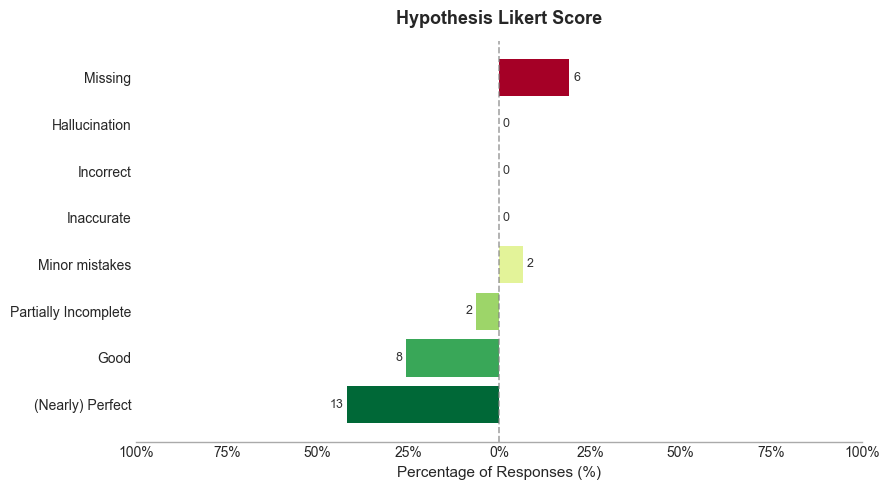

In [150]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Hypothesis Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "(Nearly) Perfect": 1,
        "Good": 2,
        "Partially Incomplete": 3,
        "Minor mistakes": 4,
        "Inaccurate": 5,
        "Incorrect": 6,
        "Hallucination": 7,
        "Missing": 8,
    }
)

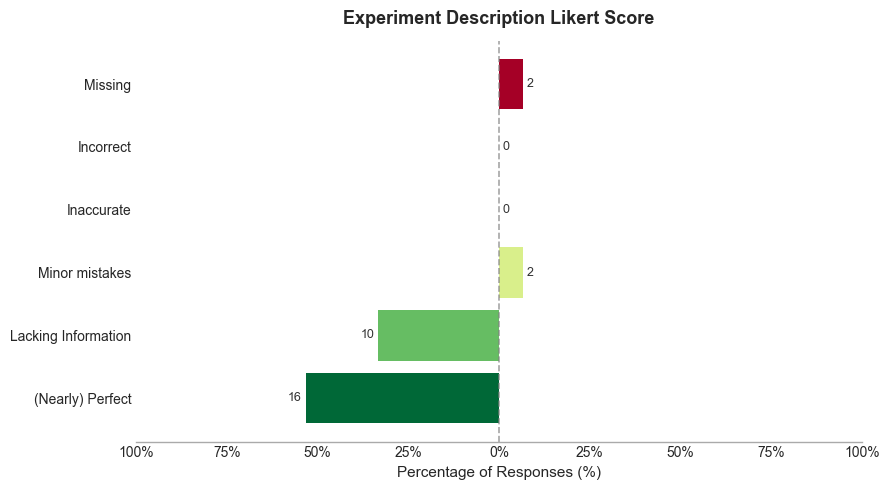

In [151]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Description Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "(Nearly) Perfect": 1,
        "Lacking Information": 2,
        "Minor mistakes": 3,
        "Inaccurate": 4,
        "Incorrect": 5,
        "Missing": 6,
    }
)

In [ ]:
# This is the specific value you want to plot (e.g., the name of the question)
FILTER_VALUE_PLACEHOLDER = 'Experiment Details Likert Score'

# 3. Generate the Plot
plot_likert(
    df=df,
    field_value=FILTER_VALUE_PLACEHOLDER,
    likert_map= {
        "Very Well": 1,
        "Well": 2,
        "Okay": 3,
        "Poorly": 4,
        "Incorrect": 5,
    }
)